# Seção 1: Geração de Sinais Discretos Básicos

Esta seção apresenta a representação matemática e computacional das sequências elementares que formam a base do Processamento Digital de Sinais (PDS). Conforme a teoria de sinais e sistemas, sinais discretos são sequências obtidas pela amostragem de sinais contínuos. Esta representação permite que fenômenos físicos sejam analisados e processados por sistemas digitais.

O código a seguir implementa a modelagem gráfica do impulso unitário, do degrau unitário e de exponenciais complexas, aplicando conceitos teóricos em simulações computacionais.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1.1 Impulso Unitário e Degrau Unitário

O **impulso unitário** $\delta[n]$ é o sinal fundamental em PDS, possuindo amplitude $1$ na origem ($n=0$) e $0$ nos demais instantes. O **degrau unitário** $u[n]$ assume valor $1$ para $n \ge 0$ e $0$ para $n < 0$.

O script abaixo define o vetor de tempo discreto $n$ e modela estas duas sequências elementares.

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8291/2497803536.py:10: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Impulso Unitário $\delta[n]$")


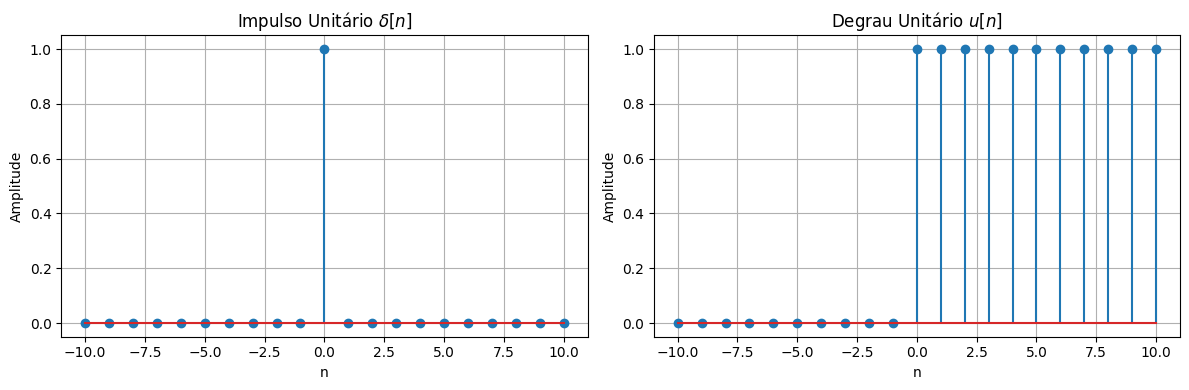

In [2]:
n = np.arange(-10, 11)

impulso = np.where(n == 0, 1, 0)
degrau = np.where(n >= 0, 1, 0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n, impulso)
plt.title("Impulso Unitário $\delta[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, degrau)
plt.title("Degrau Unitário $u[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.2 Exponencial Complexa

A **exponencial complexa discreta** é definida pela equação $x[n] = e^{j\omega n}$, onde $\omega$ representa a frequência angular discreta em radianos por amostra. Pela Relação de Euler, a sequência é decomposta em uma parte real (cosseno) e uma parte imaginária (seno).

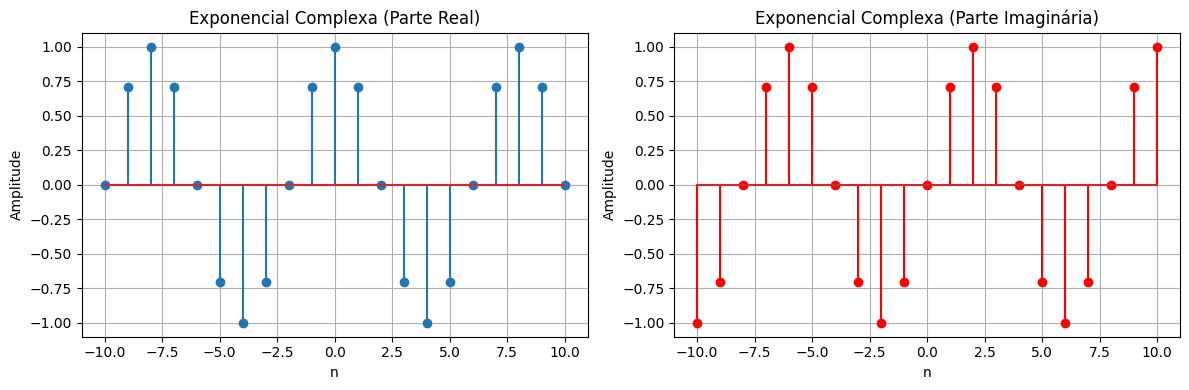

In [3]:
omega = np.pi / 4
exponencial = np.exp(1j * omega * n)

parte_real = np.real(exponencial)
parte_imaginaria = np.imag(exponencial)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n, parte_real)
plt.title("Exponencial Complexa (Parte Real)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, parte_imaginaria, linefmt='r-', markerfmt='ro')
plt.title("Exponencial Complexa (Parte Imaginária)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.3 Discussão Técnica: Relação com Sinais Reais

A representação matemática do comportamento temporal de um sensor real depende diretamente do processo de amostragem de sinais contínuos.

O eixo temporal discreto $n$, gerado nas simulações numéricas, ilustra esta discretização. Ao modelar um sinal físico adquirido digitalmente, a matemática o interpreta como uma combinação linear de impulsos deslocados e escalonados. Esta formulação conecta a teoria de sinais às aplicações tecnológicas, evidenciando como os vetores processados no código correspondem aos dados amostrados por um conversor analógico-digital (ADC) em aplicações práticas de hardware e sistemas embarcados.

## 1.4 Propriedades e Relações Fundamentais dos Sinais

As sequências elementares possuem propriedades matemáticas essenciais para a análise de sistemas lineares e invariantes no tempo. Uma característica estrutural importante é a relação direta entre o impulso unitário e o degrau unitário.

O impulso discreto pode ser obtido a partir da primeira diferença (derivada discreta) do degrau unitário, representada pela equação $\delta[n] = u[n] - u[n-1]$. De forma análoga, o degrau unitário equivale ao acúmulo (somatório) de impulsos deslocados ao longo do tempo.

O código a seguir implementa a operação de diferença no vetor do degrau unitário para comprovar a geração exata do impulso unitário.

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_8291/173680600.py:20: SyntaxWarning: invalid escape sequence '\d'
  plt.title("Primeira Diferença (u[n] - u[n-1]) = $\delta[n]$")


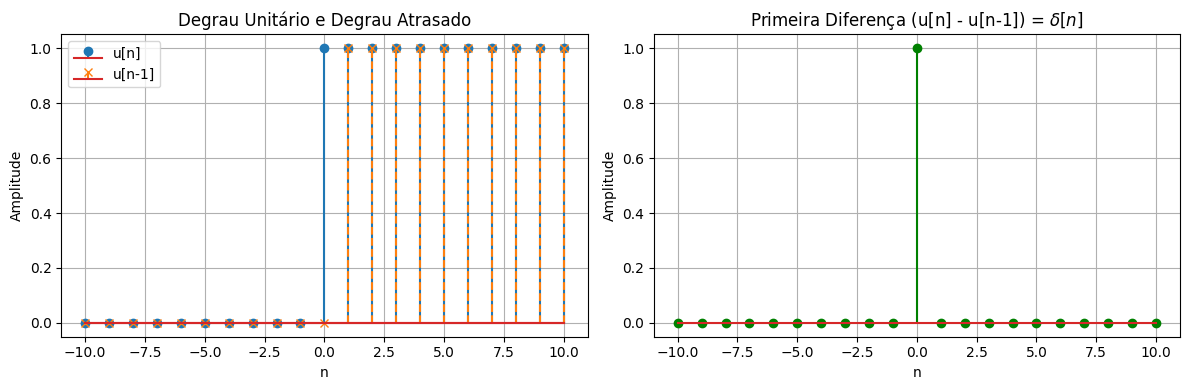

In [4]:
# Deslocamento do degrau unitário para obter u[n-1]
degrau_atrasado = np.where(n - 1 >= 0, 1, 0)

# Primeira diferença
primeira_diferenca = degrau - degrau_atrasado

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n, degrau, label='u[n]', linefmt='C0-', markerfmt='C0o')
plt.stem(n, degrau_atrasado, label='u[n-1]', linefmt='C1--', markerfmt='C1x')
plt.title("Degrau Unitário e Degrau Atrasado")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n, primeira_diferenca, linefmt='g-', markerfmt='go')
plt.title("Primeira Diferença (u[n] - u[n-1]) = $\delta[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.5 Condição de Periodicidade em Sinais Discretos

Em relação às exponenciais complexas e sinais senoidais, existe uma divergência fundamental entre o domínio contínuo e o discreto. No tempo contínuo, qualquer sinal senoidal é periódico. No tempo discreto, uma sequência senoidal ou exponencial complexa discreta $x[n] = e^{j\omega n}$ só é estritamente periódica se a frequência angular $\omega$ for um múltiplo racional de $2\pi$.

Matematicamente, a condição de periodicidade exige que exista um número inteiro $N$ tal que $x[n+N] = x[n]$, o que resulta na condição $\frac{\omega}{2\pi} = \frac{m}{N}$, onde $m$ e $N$ são inteiros.

A simulação abaixo compara um sinal discreto periódico com um sinal discreto aperiódico para ilustrar esta propriedade.

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_8291/1444917779.py:15: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Sinal Discreto Periódico ($\omega = 0.2\pi$)")
/tmp/ipykernel_8291/1444917779.py:22: SyntaxWarning: invalid escape sequence '\o'
  plt.title("Sinal Discreto Aperiódico ($\omega = 0.2$)")


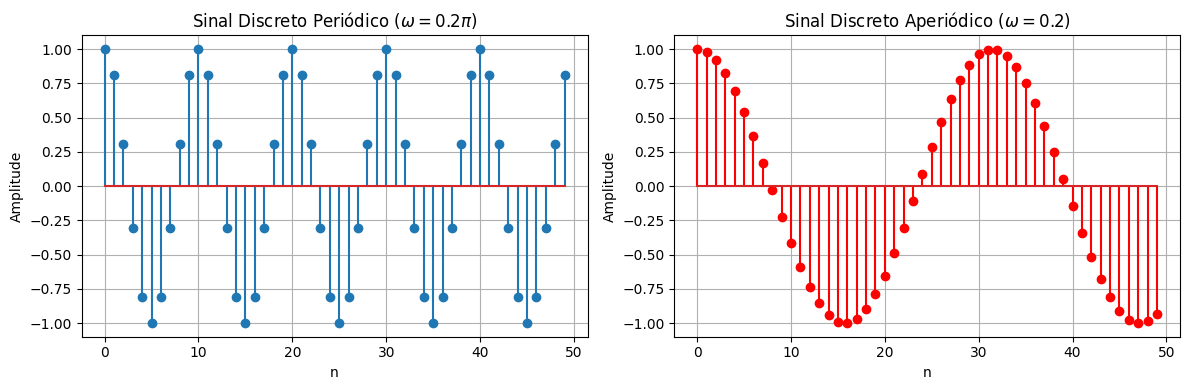

In [5]:
n_extenso = np.arange(0, 50)

# Sinal periódico: w = 0.2*pi (razão w/(2*pi) = 0.1, que é racional 1/10)
omega_periodico = 0.2 * np.pi
sinal_periodico = np.cos(omega_periodico * n_extenso)

# Sinal aperiódico: w = 0.2 (razão w/(2*pi) = 0.2/(2*pi), que é irracional)
omega_aperiodico = 0.2
sinal_aperiodico = np.cos(omega_aperiodico * n_extenso)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n_extenso, sinal_periodico)
plt.title("Sinal Discreto Periódico ($\omega = 0.2\pi$)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n_extenso, sinal_aperiodico, linefmt='r-', markerfmt='ro')
plt.title("Sinal Discreto Aperiódico ($\omega = 0.2$)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.6 Exponenciais Complexas como Autofunções de Sistemas LIT

Uma propriedade estrutural crítica das exponenciais complexas é que elas atuam como autofunções de Sistemas Lineares e Invariantes no Tempo (LIT).

Quando um sinal $x[n] = e^{j\omega n}$ é aplicado à entrada de um sistema LIT, a saída $y[n]$ resulta na exata mesma exponencial complexa, multiplicada por uma constante de valor complexo $H(e^{j\omega})$, denominada resposta em frequência do sistema. A relação matemática é expressa por $y[n] = H(e^{j\omega}) e^{j\omega n}$.

Esta propriedade demonstra que sistemas LIT afetam apenas a amplitude e a fase das componentes de frequência originais do sinal, sem criar novas frequências. A simulação a seguir aplica uma exponencial complexa a um filtro de média móvel simples (um sistema LIT) para demonstrar a preservação da oscilação fundamental, evidenciando apenas o escalonamento em amplitude e o deslocamento de fase.

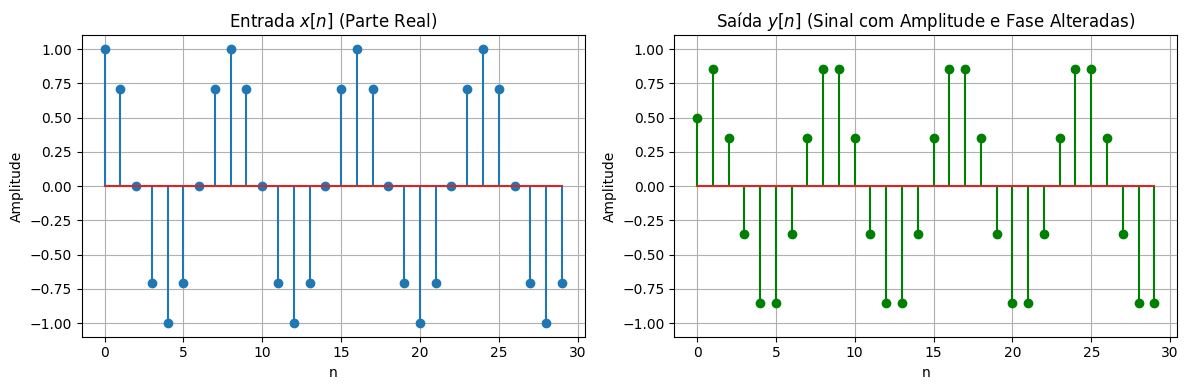

In [6]:
omega_0 = np.pi / 4
n_auto = np.arange(0, 30)
x_n = np.exp(1j * omega_0 * n_auto)

# Resposta ao impulso de um filtro de média móvel (LIT)
h_n = np.array([0.5, 0.5])
y_n = np.convolve(x_n, h_n, mode='same')

x_real = np.real(x_n)
y_real = np.real(y_n)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n_auto, x_real)
plt.title("Entrada $x[n]$ (Parte Real)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.ylim(-1.1, 1.1)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n_auto, y_real, linefmt='g-', markerfmt='go')
plt.title("Saída $y[n]$ (Sinal com Amplitude e Fase Alteradas)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.ylim(-1.1, 1.1)
plt.grid(True)

plt.tight_layout()
plt.show()

## 1.7 Discussão Técnica: Fundamentos Matemáticos e a Interface Física

A geração e a análise das sequências elementares — impulso, degrau e exponenciais complexas — estabelecem a base matemática necessária para representar o comportamento temporal de sensores reais, respondendo diretamente à primeira premissa do Problema Norteador.

Quando um sinal físico contínuo, como a leitura de temperatura de um sensor industrial ou a oscilação elétrica em um barramento de comunicação, é amostrado por um conversor analógico-digital (ADC), sua representação no domínio discreto depende intrinsecamente das funções modeladas nesta seção.

O impulso e o degrau unitário são essenciais para caracterizar a resposta transitória de sistemas digitais a eventos abruptos, como a energização de um circuito ou a recepção de um pulso de validação de dados em hardware. A análise computacional demonstra que qualquer sequência discreta arbitrária proveniente de um sensor pode ser decomposta em um somatório de impulsos deslocados e escalonados no tempo.

Além disso, a validação das exponenciais complexas como autofunções de sistemas LIT tem implicação direta no design de arquiteturas de processamento digital. Ao implementar algoritmos de filtragem em nível de transferência de registradores (RTL), a propriedade da autofunção garante que o sistema alterará apenas a amplitude e a fase do sinal de entrada, preservando a integridade do espectro de frequências original. Esta garantia estrutural é o que viabiliza o correto processamento de sinais embarcados sem corromper a informação transmitida pelo sensor.

# Seção 2: Operações com Sinais e Caracterização Energética

Esta etapa aborda as transformações matemáticas aplicadas à variável independente (tempo discreto) e à amplitude dos sinais, bem como a quantificação de sua energia e potência. Tais operações constituem a base para a manipulação de dados amostrados em algoritmos de Processamento Digital de Sinais.

O código a seguir implementa as operações de deslocamento, inversão e escalonamento, seguidas pelos cálculos numéricos de caracterização energética.

## 2.1 Deslocamento, Inversão e Escalonamento

As manipulações estruturais de uma sequência discreta $x[n]$ alteram sua posição ou magnitude:

* **Deslocamento Temporal ($x[n-k]$):** Translada o sinal no eixo do tempo. Um valor de $k > 0$ representa um atraso (deslocamento para a direita), enquanto $k < 0$ representa um avanço (deslocamento para a esquerda).
* **Inversão Temporal ($x[-n]$):** Reflete a sequência em torno da origem ($n=0$), revertendo a ordem cronológica das amostras.
* **Escalonamento de Amplitude ($c \cdot x[n]$):** Multiplica a magnitude de cada amostra por uma constante $c$, caracterizando amplificação ($|c| > 1$) ou atenuação ($|c| < 1$).

A simulação abaixo define um pulso retangular arbitrário de duração finita e aplica estas três operações.

<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_8291/2036039661.py:37: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Escalonamento de Amplitude $2.5 \cdot x[n]$")


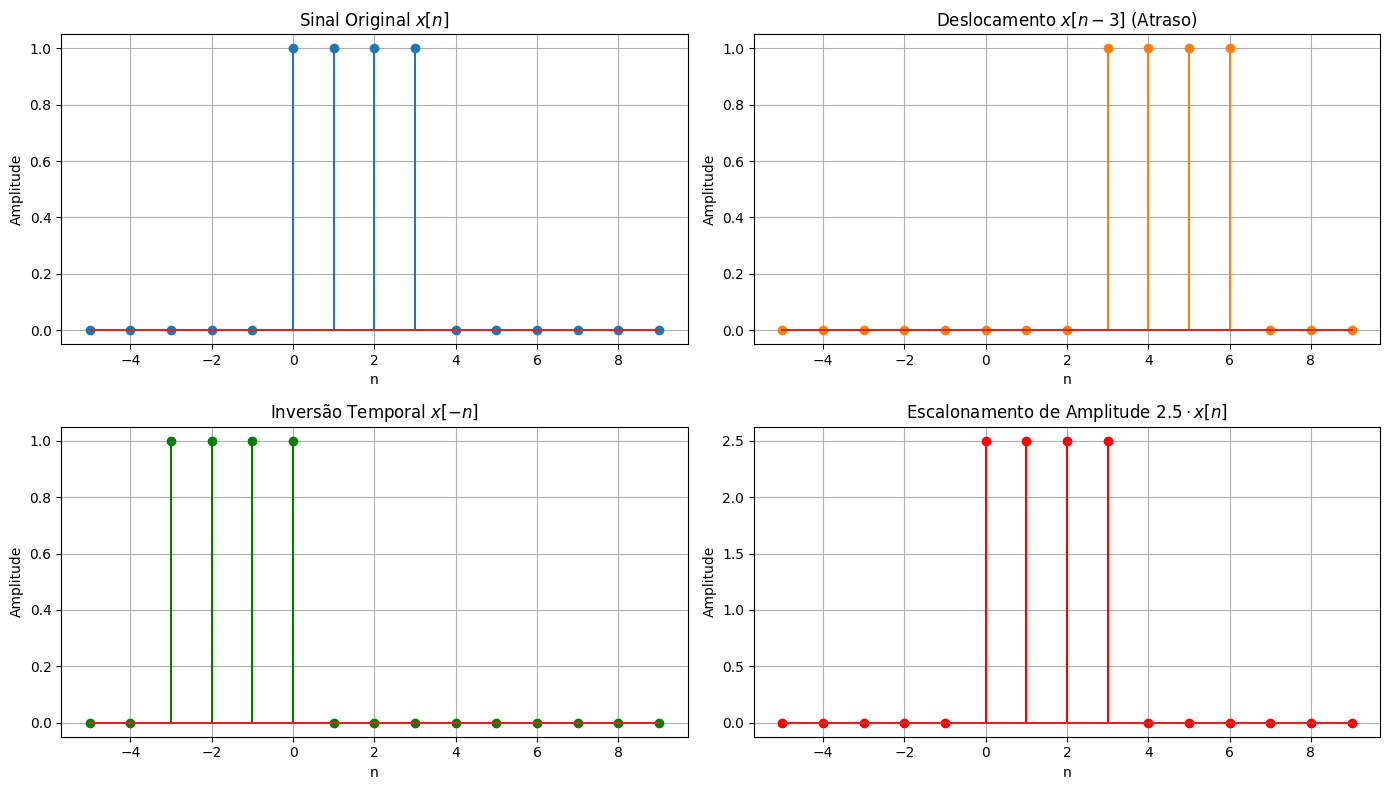

In [7]:
n_op = np.arange(-5, 10)

# Sinal original: Pulso retangular com amplitude 1 entre n=0 e n=3
x_n = np.where((n_op >= 0) & (n_op <= 3), 1, 0)

# Operações
k = 3
x_deslocado = np.where((n_op - k >= 0) & (n_op - k <= 3), 1, 0)
x_invertido = np.where((-n_op >= 0) & (-n_op <= 3), 1, 0)
x_escalonado = 2.5 * x_n

plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.stem(n_op, x_n)
plt.title("Sinal Original $x[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.stem(n_op, x_deslocado, linefmt='C1-', markerfmt='C1o')
plt.title(f"Deslocamento $x[n-{k}]$ (Atraso)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.stem(n_op, x_invertido, linefmt='g-', markerfmt='go')
plt.title("Inversão Temporal $x[-n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.stem(n_op, x_escalonado, linefmt='r-', markerfmt='ro')
plt.title("Escalonamento de Amplitude $2.5 \cdot x[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 2.2 Energia e Potência Média de Sinais

A classificação dos sinais quanto ao seu conteúdo energético determina as ferramentas analíticas aplicáveis ao sistema.

A **Energia Total ($E$)** de um sinal em tempo discreto é definida pelo somatório do módulo ao quadrado de suas amostras:

$$E = \sum_{n=-\infty}^{\infty} |x[n]|^2$$

Sinais que possuem energia total finita ($0 < E < \infty$) são classificados como "sinais de energia". Nestes casos, a potência média é nula. Geralmente, sinais de duração finita pertencem a esta categoria.

A **Potência Média ($P$)** quantifica a taxa de entrega de energia ao longo do tempo para sinais de duração infinita:

$$P = \lim_{N \to \infty} \frac{1}{2N+1} \sum_{n=-N}^{N} |x[n]|^2$$

Sinais com potência média finita e não nula ($0 < P < \infty$) são classificados como "sinais de potência", possuindo energia total infinita. Exemplos clássicos incluem sinais periódicos e ruído contínuo.

O script a seguir calcula a energia do pulso retangular de duração finita gerado na etapa anterior e a potência média de um sinal senoidal contínuo (aproximado computacionalmente por um vetor extenso).

In [8]:
# Cálculo de Energia do sinal finito x[n]
energia_x = np.sum(np.abs(x_n)**2)

# Geração de um sinal periódico extenso para cálculo de potência
N_amostras = 1000
n_pot = np.arange(0, N_amostras)
sinal_potencia = np.cos(0.2 * np.pi * n_pot)

# Cálculo da Potência Média (aproximação para N finito grande)
potencia_media = np.sum(np.abs(sinal_potencia)**2) / N_amostras

print(f"Energia do sinal x[n] (pulso finito): {energia_x} Joules (unidade arbitrária)")
print(f"Potência Média do sinal senoidal: {potencia_media:.4f} Watts (unidade arbitrária)")

Energia do sinal x[n] (pulso finito): 4 Joules (unidade arbitrária)
Potência Média do sinal senoidal: 0.5000 Watts (unidade arbitrária)


## 2.3 Discussão Técnica: Impacto Físico das Operações e Análise Energética

A transposição matemática das operações fundamentais possui mapeamento direto em arquiteturas de hardware digital e sistemas embarcados.

A operação de deslocamento temporal ($x[n-k]$) equivale fisicamente à introdução de memória no sistema. Em linguagens de descrição de hardware, o atraso de $k$ amostras de um fluxo de dados é implementado instanciando uma cadeia de $k$ registradores, controlados pelo mesmo sinal de *clock*. A inversão temporal ($x[-n]$) não pode ser implementada em tempo real (pois requer acesso a amostras futuras), limitando seu uso a processamentos *offline* onde todo o bloco de memória já foi adquirido. O escalonamento de amplitude é fisicamente implementado por meio de deslocadores lógicos de bits (*bit-shifts*) ou multiplicadores digitais.

Por fim, a quantificação de energia e potência orienta o tratamento digital do sensor avaliado no Problema Norteador. Transientes e leituras pontuais de aquisição atuam sob a classe de sinais de energia. Por outro lado, o ruído eletromagnético inerente a barramentos físicos e portadoras contínuas caracterizam-se como sinais de potência. A correta caracterização energética permite dimensionar os tamanhos das palavras de dados na aritmética de ponto fixo do processador, evitando problemas de transbordamento numérico (*overflow*) durante a execução dos algoritmos.

## 2.4 Decomposição em Sinais Par e Ímpar

A operação de inversão temporal permite decompor qualquer sequência discreta $x[n]$ em uma soma de duas componentes fundamentais: a parte par ($x_e[n]$) e a parte ímpar ($x_o[n]$).

* **Componente Par:** Apresenta simetria em relação ao eixo vertical, satisfazendo a condição $x_e[n] = x_e[-n]$. É calculada por $x_e[n] = \frac{1}{2}(x[n] + x[-n])$.
* **Componente Ímpar:** Apresenta antissimetria, satisfazendo $x_o[n] = -x_o[-n]$. A origem é obrigatoriamente nula ($x_o[0] = 0$). É calculada por $x_o[n] = \frac{1}{2}(x[n] - x[-n])$.

O código a seguir gera um sinal assimétrico (uma rampa causal) e realiza a extração exata de suas componentes par e ímpar.


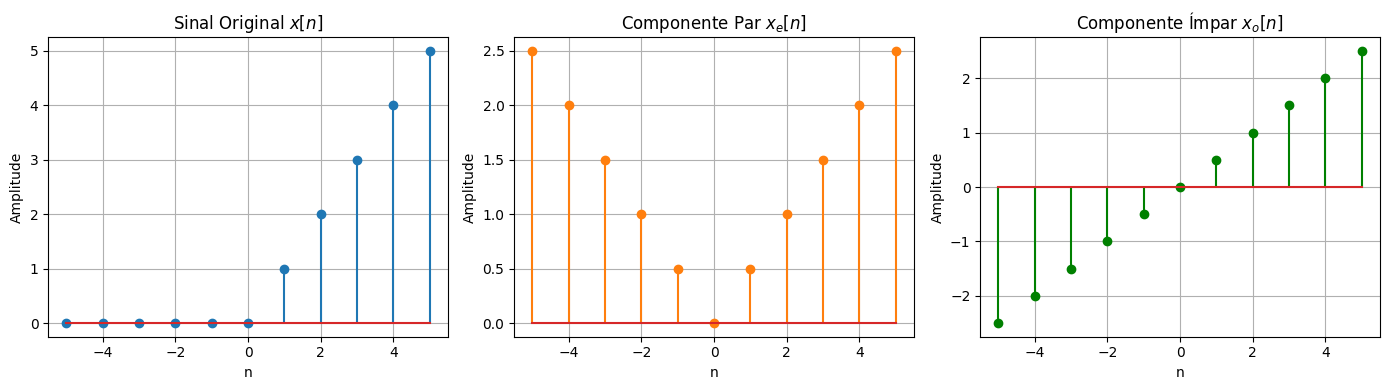

In [10]:
n_sim = np.arange(-5, 6)
# Sinal original: Rampa causal
x_rampa = np.where(n_sim >= 0, n_sim, 0)

# Inversão temporal pura (possível pois o vetor n_sim é simétrico em torno de 0)
x_rampa_inv = np.flip(x_rampa)

# Cálculo das componentes
x_par = 0.5 * (x_rampa + x_rampa_inv)
x_impar = 0.5 * (x_rampa - x_rampa_inv)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.stem(n_sim, x_rampa)
plt.title("Sinal Original $x[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.stem(n_sim, x_par, linefmt='C1-', markerfmt='C1o')
plt.title("Componente Par $x_e[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(n_sim, x_impar, linefmt='g-', markerfmt='go')
plt.title("Componente Ímpar $x_o[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 2.5 Escalonamento no Tempo (Decimação)

Diferente do escalonamento de amplitude abordado anteriormente, o escalonamento da variável independente altera a taxa com a qual o sinal é percorrido.

A operação $y[n] = x[M \cdot n]$, onde $M$ é um número inteiro maior que 1, representa a compressão temporal ou **decimação**. No domínio discreto, comprimir um sinal resulta na perda irrecuperável de informação, pois mantêm-se apenas as amostras cujos índices são múltiplos de $M$, descartando as demais.

A simulação abaixo demonstra a decimação de uma onda senoidal por um fator $M = 2$.

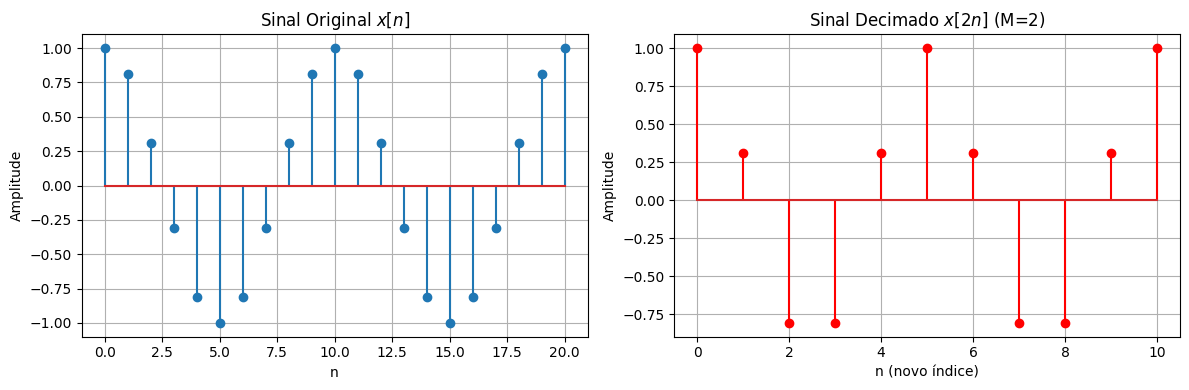

In [11]:
n_temp = np.arange(0, 21)
x_senoidal = np.cos(0.2 * np.pi * n_temp)

# Escalonamento no tempo (Decimação por fator M=2)
M = 2
n_decimado = n_temp[::M]
x_decimado = x_senoidal[::M]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n_temp, x_senoidal)
plt.title("Sinal Original $x[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
# Ajuste do eixo x para refletir a nova indexação temporal decima
plt.stem(np.arange(len(n_decimado)), x_decimado, linefmt='r-', markerfmt='ro')
plt.title("Sinal Decimado $x[2n]$ (M=2)")
plt.xlabel("n (novo índice)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 2.6 Discussão Técnica: Aplicação Estrutural em Hardware

A decomposição em par e ímpar possui relevância matemática no cálculo de transformadas, mas é o escalonamento no tempo que apresenta impacto físico crítico em engenharia.

A operação de decimação simulada ($x[M \cdot n]$) traduz-se diretamente para a alteração de taxas de amostragem ( *Multirate Signal Processing* ). Em projetos de hardware digital de alta performance, a decimação é frequentemente empregada após conversores analógico-digitais de sobreamostragem (como ADCs Sigma-Delta). A redução da taxa de dados diminui a frequência de operação exigida pela lógica sequencial subsequente, otimizando o consumo de potência dinâmica dos registradores e simplificando o cumprimento das restrições de tempo (*timing constraints*) durante a etapa de síntese física (RTL para *gate-level*). A perda de dados inerente ao processo matemático é controlada fisicamente pelo uso de filtros *anti-aliasing* prévios.

# Seção 3: Modelagem e Classificação de Sistemas Discretos (Parte 1)

A caracterização de sistemas discretos exige a identificação das propriedades que definem a relação dinâmica entre a sequência de entrada $x[n]$ e a sequência de saída $y[n]$. A classificação matemática do sistema determina sua viabilidade de implementação e as ferramentas analíticas que podem ser utilizadas para o seu estudo.

Esta seção implementa computacionalmente a verificação de sistemas com e sem memória, bem como o teste de linearidade. As propriedades restantes (causalidade, estabilidade BIBO e invariância no tempo) serão abordadas na sequência.

## 3.1 Sistemas com e sem Memória

Um sistema é classificado como **sem memória** se a saída no instante $n$ depende estritamente da entrada no exato mesmo instante $n$. Matematicamente, a relação assume a forma $y[n] = f(x[n])$.

O sistema possui **memória** se a saída depender de valores passados (ex: $x[n-1]$) ou futuros (ex: $x[n+1]$) da entrada. O armazenamento destas amostras requer elementos de estado.

O código abaixo modela um sistema sem memória ($y_1[n] = 2 \cdot x[n]$) e um sistema com memória ($y_2[n] = x[n] + x[n-1]$) e simula a resposta a um pulso de entrada.

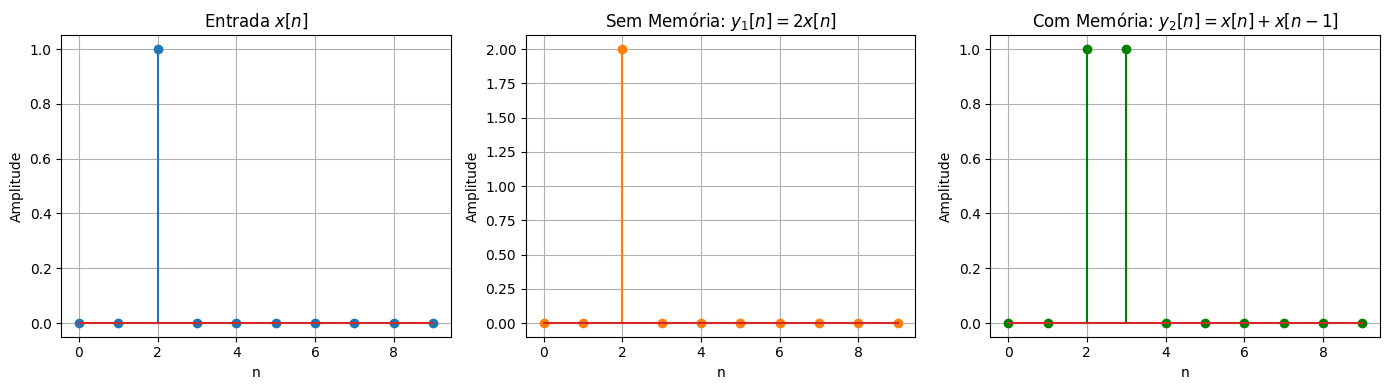

In [12]:
n_sys = np.arange(0, 10)
# Entrada: Pulso unitário em n=2
x_entrada = np.where(n_sys == 2, 1, 0)

# Sistema sem memória: y1[n] = 2 * x[n]
y1_sem_memoria = 2 * x_entrada

# Sistema com memória: y2[n] = x[n] + x[n-1]
# A função np.roll é usada para deslocar o array, simulando o atraso de 1 amostra
x_atrasado = np.roll(x_entrada, 1)
x_atrasado[0] = 0 # Condição inicial nula
y2_com_memoria = x_entrada + x_atrasado

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.stem(n_sys, x_entrada)
plt.title("Entrada $x[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.stem(n_sys, y1_sem_memoria, linefmt='C1-', markerfmt='C1o')
plt.title("Sem Memória: $y_1[n] = 2x[n]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(n_sys, y2_com_memoria, linefmt='g-', markerfmt='go')
plt.title("Com Memória: $y_2[n] = x[n] + x[n-1]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 3.2 Linearidade (Princípio da Superposição)

Sistemas lineares obedecem ao Princípio da Superposição, que engloba duas propriedades simultâneas:
1. **Aditividade:** A resposta a uma soma de entradas é a soma das respostas individuais. $T\{x_1[n] + x_2[n]\} = T\{x_1[n]\} + T\{x_2[n]\}$
2. **Homogeneidade:** Escalonar a entrada por uma constante resulta no escalonamento proporcional da saída. $T\{a \cdot x[n]\} = a \cdot T\{x[n]\}$

A equação geral que define a linearidade é $T\{a \cdot x_1[n] + b \cdot x_2[n]\} = a \cdot y_1[n] + b \cdot y_2[n]$.

A simulação a seguir testa um sistema linear (multiplicação por constante) e um sistema não linear (elevação ao quadrado) aplicando a superposição computacionalmente.

In [13]:
x1 = np.where(n_sys == 1, 2, 0)
x2 = np.where(n_sys == 2, 3, 0)
a, b = 2, 0.5

# Entrada combinada: a*x1[n] + b*x2[n]
x_combinada = a * x1 + b * x2

# --- Teste no Sistema 1 (Linear): y[n] = 3 * x[n] ---
def sistema_linear(x): return 3 * x

y_combinada_lin = sistema_linear(x_combinada)
y_superposicao_lin = a * sistema_linear(x1) + b * sistema_linear(x2)
erro_linear = np.max(np.abs(y_combinada_lin - y_superposicao_lin))

# --- Teste no Sistema 2 (Não Linear): y[n] = (x[n])^2 ---
def sistema_nao_linear(x): return x**2

y_combinada_nlin = sistema_nao_linear(x_combinada)
y_superposicao_nlin = a * sistema_nao_linear(x1) + b * sistema_nao_linear(x2)
erro_nao_linear = np.max(np.abs(y_combinada_nlin - y_superposicao_nlin))

print(f"Erro no sistema y[n] = 3x[n]: {erro_linear} (Se 0, é Linear)")
print(f"Erro no sistema y[n] = x[n]^2: {erro_nao_linear} (Se > 0, é Não Linear)")

Erro no sistema y[n] = 3x[n]: 0.0 (Se 0, é Linear)
Erro no sistema y[n] = x[n]^2: 8.0 (Se > 0, é Não Linear)


## 3.3 Causalidade

Um sistema é classificado como **causal** se a saída no instante $n$ depende estritamente de valores presentes e passados da entrada ($x[n], x[n-1], x[n-2], \dots$). Se o sistema depender de amostras futuras ($x[n+1]$), ele é **não causal**.

Matematicamente, em um sistema causal, se a entrada é nula para $n < n_0$, a saída obrigatoriamente será nula para $n < n_0$. O sistema não pode antecipar uma excitação.

A simulação abaixo compara um sistema causal ($y_c[n] = x[n] + x[n-1]$) e um sistema não causal ($y_{nc}[n] = x[n+1]$) submetidos ao mesmo pulso de entrada no instante $n=2$.

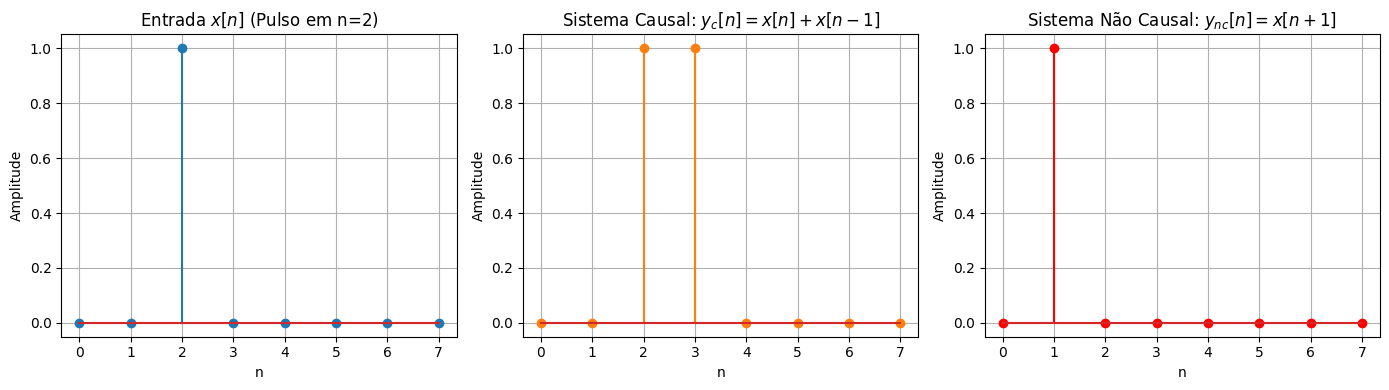

In [14]:
n_sys = np.arange(0, 8)
x_entrada = np.where(n_sys == 2, 1, 0)

y_causal = x_entrada + np.concatenate(([0], x_entrada[:-1]))

y_nao_causal = np.concatenate((x_entrada[1:], [0]))

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.stem(n_sys, x_entrada)
plt.title("Entrada $x[n]$ (Pulso em n=2)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.stem(n_sys, y_causal, linefmt='C1-', markerfmt='C1o')
plt.title("Sistema Causal: $y_c[n] = x[n] + x[n-1]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.stem(n_sys, y_nao_causal, linefmt='r-', markerfmt='ro')
plt.title("Sistema Não Causal: $y_{nc}[n] = x[n+1]$")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 3.4 Invariância no Tempo

Um sistema é **invariante no tempo** se suas características de processamento permanecem constantes. Um deslocamento de $k$ amostras na entrada deve resultar em um deslocamento idêntico de $k$ amostras na saída, sem alterar o formato do sinal. A condição é expressa por $T\{x[n-k]\} = y[n-k]$.

Se os coeficientes do sistema dependerem explicitamente da variável $n$, o sistema é **variante no tempo**.

O script abaixo testa a invariância aplicando um atraso de 2 amostras em um sistema invariante ($y_1[n] = 2x[n]$) e em um sistema variante ($y_2[n] = n \cdot x[n]$).

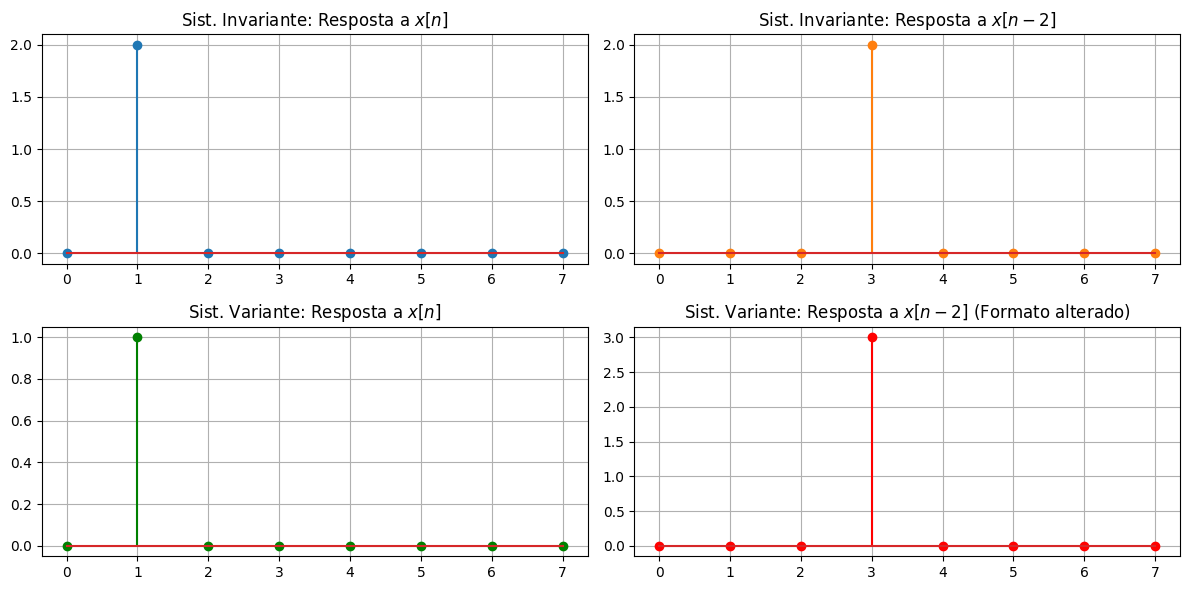

In [15]:
x_original = np.where(n_sys == 1, 1, 0)
x_atrasado = np.where(n_sys == 3, 1, 0)

def sist_invariante(x): return 2 * x
def sist_variante(x, n): return n * x

y1_orig = sist_invariante(x_original)
y1_atr = sist_invariante(x_atrasado)

y2_orig = sist_variante(x_original, n_sys)
y2_atr = sist_variante(x_atrasado, n_sys)

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.stem(n_sys, y1_orig)
plt.title("Sist. Invariante: Resposta a $x[n]$")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.stem(n_sys, y1_atr, linefmt='C1-', markerfmt='C1o')
plt.title("Sist. Invariante: Resposta a $x[n-2]$")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.stem(n_sys, y2_orig, linefmt='g-', markerfmt='go')
plt.title("Sist. Variante: Resposta a $x[n]$")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.stem(n_sys, y2_atr, linefmt='r-', markerfmt='ro')
plt.title("Sist. Variante: Resposta a $x[n-2]$ (Formato alterado)")
plt.grid(True)

plt.tight_layout()
plt.show()

## 3.5 Estabilidade BIBO

A propriedade **BIBO** (*Bounded-Input Bounded-Output*) determina que qualquer entrada de amplitude limitada produzirá uma saída de amplitude limitada. Se $|x[n]| \le M_x < \infty$, então obrigatoriamente $|y[n]| \le M_y < \infty$.

Sistemas instáveis acumulam energia indefinidamente. O código simula a resposta de um acumulador ($y[n] = y[n-1] + x[n]$) ao degrau unitário, evidenciando a instabilidade em contraste com um filtro estável de média móvel.

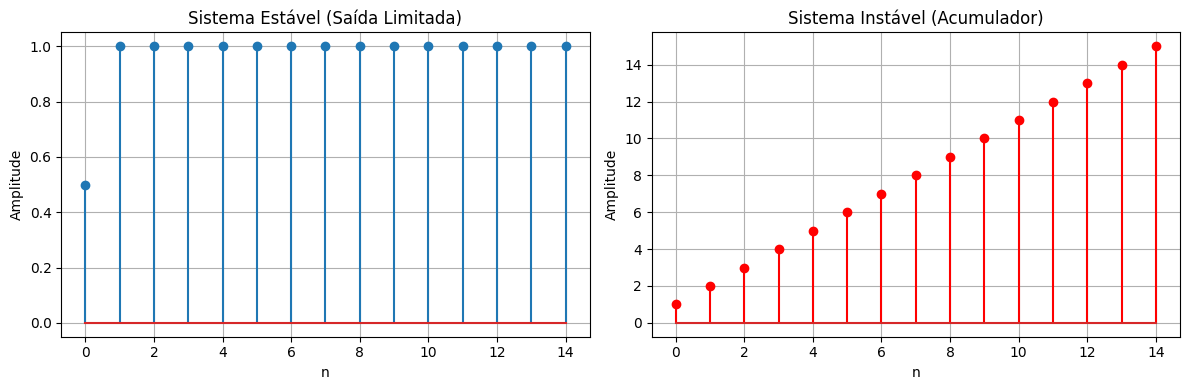

In [16]:
n_bibo = np.arange(0, 15)
x_degrau = np.ones(15)

y_estavel = 0.5 * x_degrau + 0.5 * np.concatenate(([0], x_degrau[:-1]))

y_instavel = np.cumsum(x_degrau)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n_bibo, y_estavel)
plt.title("Sistema Estável (Saída Limitada)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n_bibo, y_instavel, linefmt='r-', markerfmt='ro')
plt.title("Sistema Instável (Acumulador)")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()

## 3.6 Invertibilidade

Um sistema é invertível se entradas distintas produzem saídas sempre distintas. Esta injeção permite a construção de um sistema inverso, denotado por $H^{-1}$, que, ao ser colocado em cascata com o sistema original $H$, recupera perfeitamente o sinal de entrada $x[n]$.

A simulação demonstra a recuperação de um sinal após passar por um sistema invertível.

In [17]:
x_sinal = np.array([1, -2, 3, -1, 0, 2])
n_inv = np.arange(len(x_sinal))

y_saida = 2 * x_sinal

x_recuperado = 0.5 * y_saida

erro_recuperacao = np.max(np.abs(x_sinal - x_recuperado))
print(f"Erro máximo de recuperação do sinal: {erro_recuperacao}")

Erro máximo de recuperação do sinal: 0.0


## 3.7 Discussão Técnica: Propriedades Matemáticas no Projeto Físico

A análise teórica destas propriedades estruturais é o que define a viabilidade de implementação física de algoritmos de processamento digital. As equações matemáticas traduzem-se diretamente em restrições de *hardware*.

A exigência de causalidade é absoluta para sistemas que operam em tempo real. A dependência de amostras futuras ($x[n+1]$) é fisicamente irrealizável sem uma máquina do tempo. Projetos de RTL (*Register-Transfer Level*) baseados em SystemVerilog utilizam bancos de registradores estritamente para armazenar amostras passadas, alinhando a teoria matemática à lógica sequencial tangível.

A invariância no tempo garante que a lógica combinacional sintetizada — como somadores e multiplicadores instanciados — não precise de atualizações de coeficientes a cada ciclo de *clock*, permitindo a reutilização eficiente da área de silício no encapsulamento final do circuito integrado.

Por fim, a estabilidade BIBO previne falhas catastróficas nas unidades lógicas e aritméticas (ALUs). Em *hardware* operando com aritmética de ponto fixo, um sistema instável como o acumulador simulado excederá rapidamente a capacidade de bits dos registradores, gerando *overflow* numérico e corrupção total do sinal. Durante a verificação de *design*, ferramentas de EDA executam baterias de testes *testbenches* para assegurar que a arquitetura digital preserve a estabilidade BIBO sob qualquer excitação proveniente do sensor.

## 3.8 Sistemas Recursivos e Não Recursivos (FIR e IIR)

Além das propriedades clássicas, os sistemas discretos são divididos pela presença ou ausência de realimentação (*feedback*) em sua equação de diferenças:

* **Sistemas Não Recursivos (FIR - *Finite Impulse Response*):** A saída $y[n]$ depende apenas de valores presentes e passados da entrada $x[n]$. A resposta ao impulso tem duração finita. A equação assume a forma: $y[n] = \sum_{k=0}^{M} b_k x[n-k]$.
* **Sistemas Recursivos (IIR - *Infinite Impulse Response*):** A saída $y[n]$ depende não apenas da entrada, mas também de valores passados da própria saída ($y[n-1], y[n-2], \dots$). A resposta ao impulso decai infinitamente no tempo. A equação geral é: $y[n] = \sum_{k=0}^{M} b_k x[n-k] - \sum_{k=1}^{N} a_k y[n-k]$.

A simulação abaixo contrasta a resposta ao impulso de um filtro FIR (média móvel) com um filtro IIR (acumulador com vazamento).

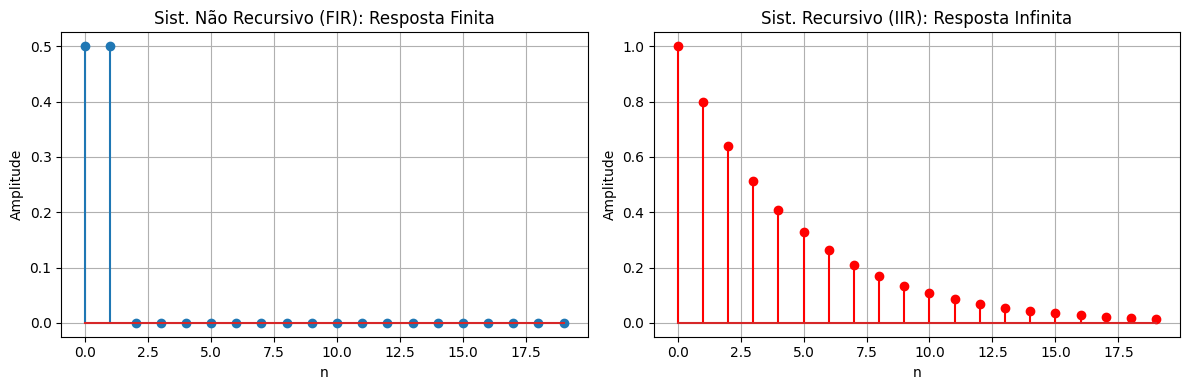

In [18]:
n_rec = np.arange(0, 20)
impulso_in = np.where(n_rec == 0, 1, 0)

# Sistema Não Recursivo (FIR): y[n] = 0.5*x[n] + 0.5*x[n-1]
y_fir = 0.5 * impulso_in + 0.5 * np.concatenate(([0], impulso_in[:-1]))

# Sistema Recursivo (IIR): y[n] = 0.8*y[n-1] + x[n]
y_iir = np.zeros(len(n_rec))
for i in range(len(n_rec)):
    if i == 0:
        y_iir[i] = impulso_in[i]
    else:
        y_iir[i] = 0.8 * y_iir[i-1] + impulso_in[i]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.stem(n_rec, y_fir)
plt.title("Sist. Não Recursivo (FIR): Resposta Finita")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(n_rec, y_iir, linefmt='r-', markerfmt='ro')
plt.title("Sist. Recursivo (IIR): Resposta Infinita")
plt.xlabel("n")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()